# 1 — Validating the pipeline on synthetic data

Before trusting persistent homology on cell coordinates, we check that it recovers the ground-truth topology of point clouds whose shape we already know, and that it degrades gracefully under noise.

Three shapes with increasing difficulty, plus a pure-noise control:

| Shape | Expected $H_0$ | Expected $H_1$ |
|---|---|---|
| Circle ($1$-sphere in $\mathbb{R}^2$) | 1 component | 1 loop |
| Torus (in $\mathbb{R}^3$) | 1 component | 2 loops |
| Klein bottle (in $\mathbb{R}^4$) | 1 component | non-trivial |
| Uniform noise | no persistent feature far from the diagonal | — |

The reference used in the report is the circle experiment (§5.1); the torus and the Klein bottle were the exploratory phase that guided the implementation choices.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import persim
import ripser
from persim import PersistenceImager, PersLandscapeApprox, bottleneck, bottleneck_matching
from persim.landscapes import plot_landscape_simple

from statapp_tda.synthetic import (
    klein_bottle_r4,
    klein_bottle_r4_noisy,
    project_r4_to_r3,
    spheres_clean_and_noisy,
    torus_point_cloud,
    uniform_bounding_box_noise,
)

## 1.1 Circles: the reference experiment

A clean circle and a circle with additive Gaussian noise ($\sigma = 0.2$). The ground truth is
unambiguous: one connected component, one loop.

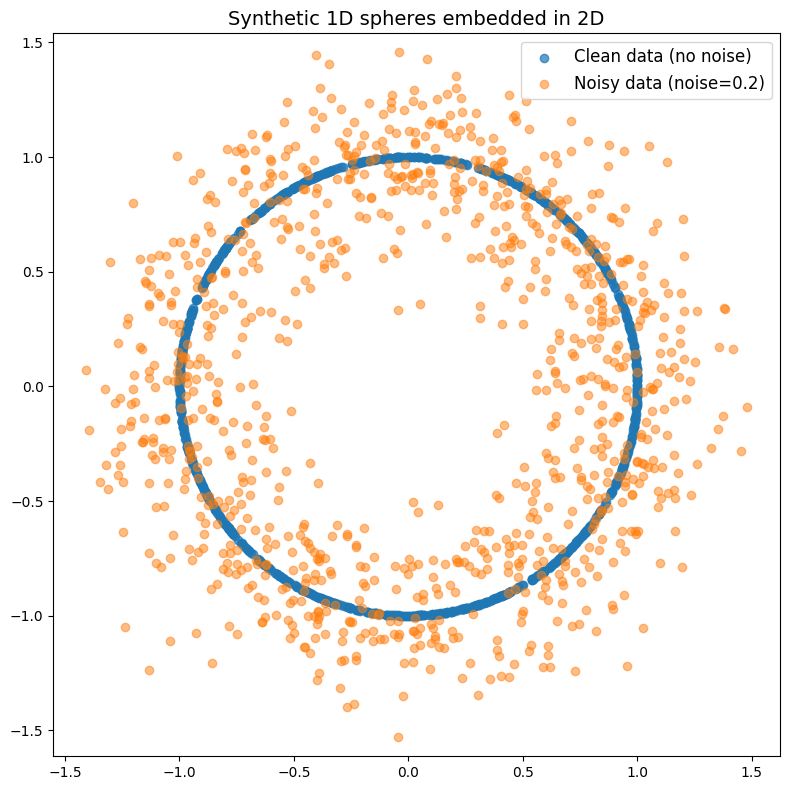

In [2]:
data_clean, data_noisy = spheres_clean_and_noisy(n=1000, noise=0.2)

plt.figure(figsize=(8, 8))
plt.scatter(data_clean[:, 0], data_clean[:, 1], label="Clean data (no noise)", alpha=0.7)
plt.scatter(data_noisy[:, 0], data_noisy[:, 1], label="Noisy data (noise=0.2)", alpha=0.5)
plt.axis("equal")
plt.legend(fontsize=12)
plt.title("Synthetic 1D spheres embedded in 2D", fontsize=14)
plt.tight_layout()
plt.show()

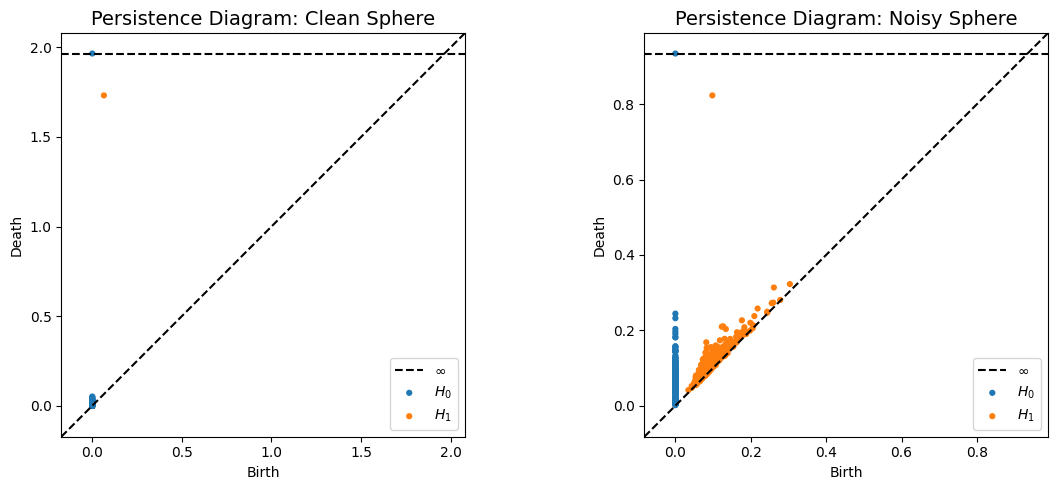

In [3]:
dgms_clean = ripser.ripser(data_clean)["dgms"]
dgms_noisy = ripser.ripser(data_noisy)["dgms"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
persim.plot_diagrams(dgms_clean, show=False, ax=axes[0])
axes[0].set_title("Persistence Diagram: Clean Sphere", fontsize=14)
persim.plot_diagrams(dgms_noisy, show=False, ax=axes[1])
axes[1].set_title("Persistence Diagram: Noisy Sphere", fontsize=14)
plt.tight_layout()
plt.show()

In both regimes a single $H_1$ point sits far from the diagonal: the circular void is recovered.
Noise only adds short-lived features *near* the diagonal, which is exactly the behaviour the
stability theorems predict and the reason persistence is usable on noisy biological data.

## 1.2 Torus: two independent loops, and what noise does to them

A torus has $H_1$ of rank 2. We increase the noise level and watch the two loops lose
persistence.

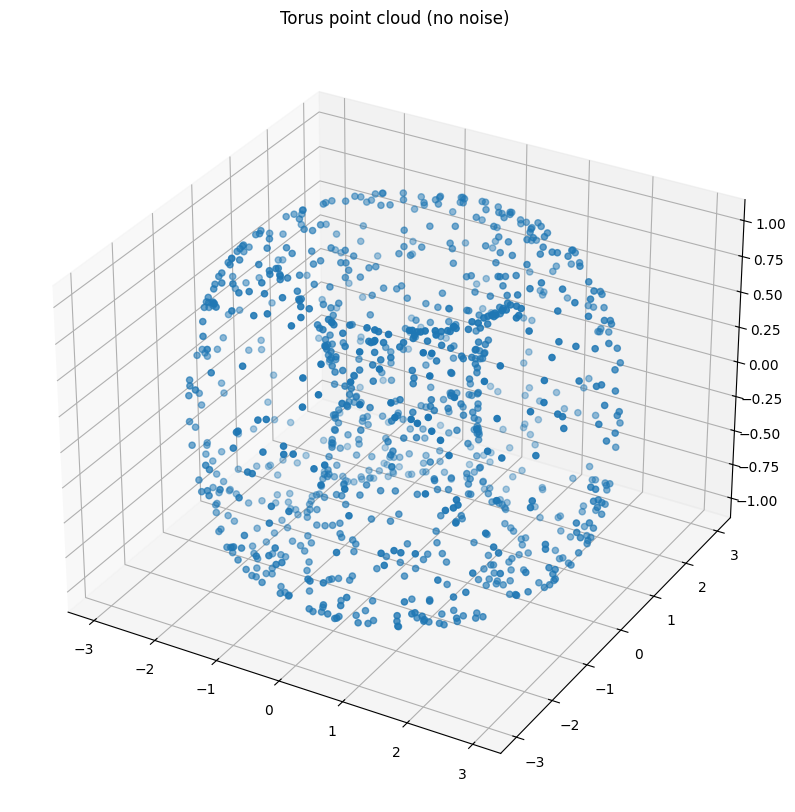

In [4]:
data_torus = torus_point_cloud(n=1000, noise=0.0)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection="3d")
ax.scatter(data_torus[:, 0], data_torus[:, 1], data_torus[:, 2])
ax.set_title("Torus point cloud (no noise)")
plt.show()

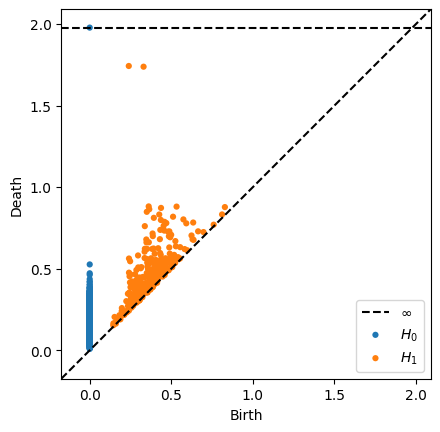

In [5]:
dgm_torus = ripser.ripser(data_torus, maxdim=1)["dgms"]
persim.plot_diagrams(dgm_torus, show=True)

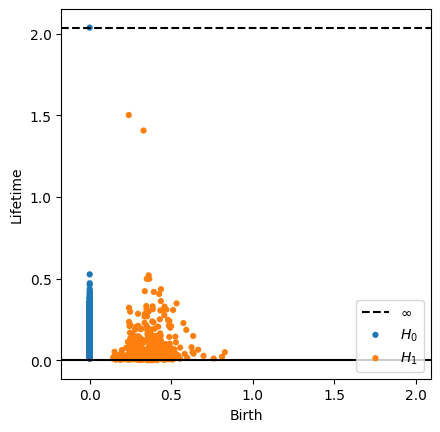

In [6]:
persim.plot_diagrams(dgm_torus, lifetime=True, show=True)

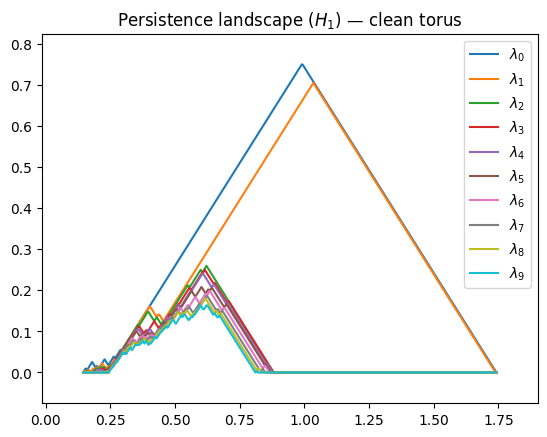

In [7]:
pla = PersLandscapeApprox(dgms=dgm_torus, hom_deg=1)
ax = plot_landscape_simple(pla, depth_range=range(10))
plt.title("Persistence landscape ($H_1$) — clean torus")
plt.show()

The two most persistent $H_1$ features correspond to the two independent loops of the torus, and
they dominate the first two landscape depths. This is the property the classification pipeline
relies on: the landscape encodes *how much* topology is present, at *which* scale.

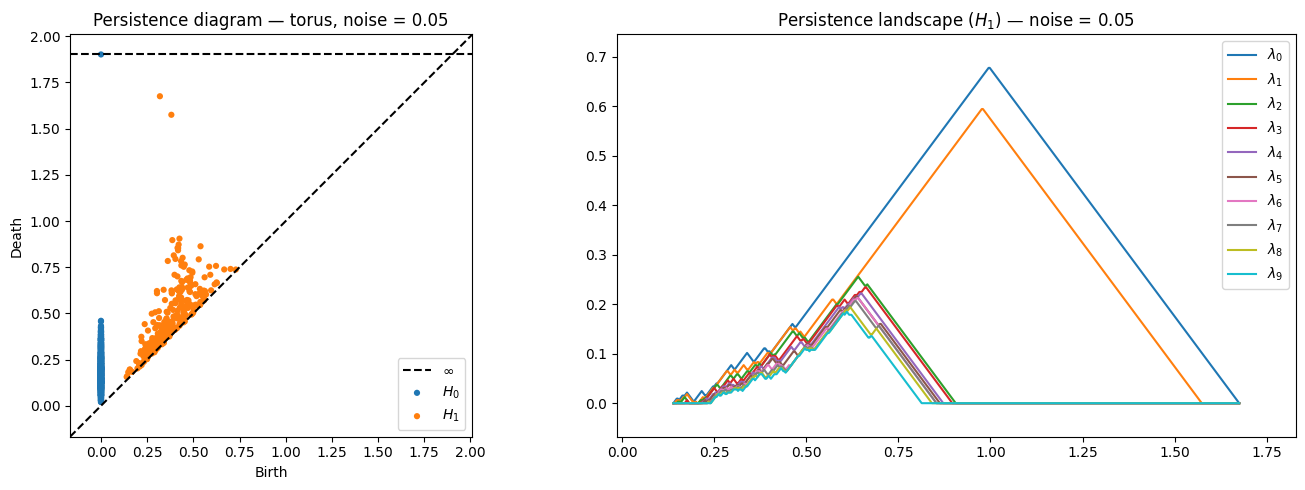

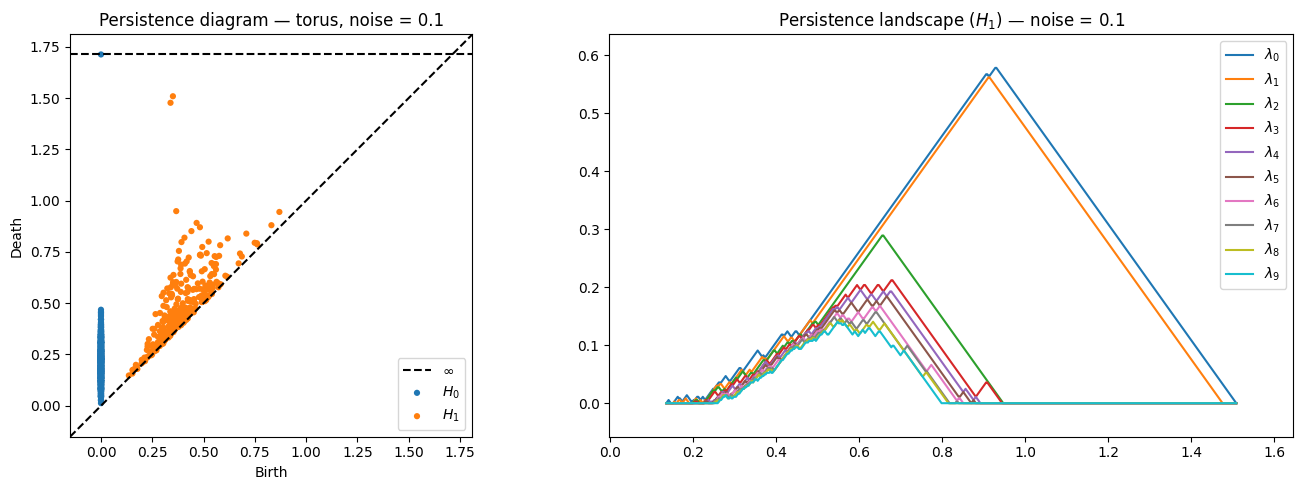

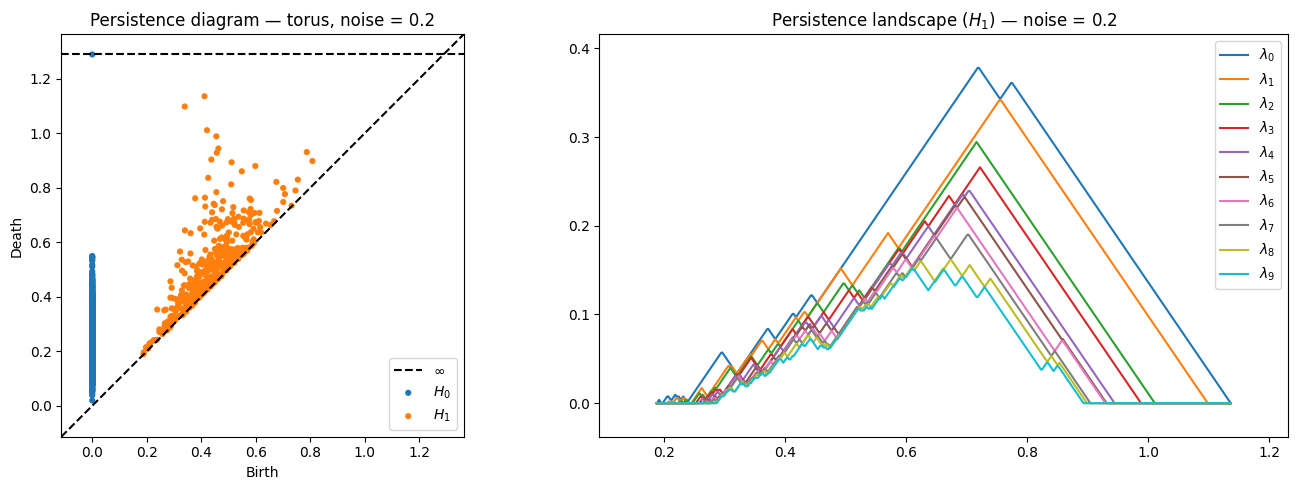

In [8]:
for noise in [0.05, 0.1, 0.2]:
    data_n = torus_point_cloud(n=1000, noise=noise)
    dgm_n = ripser.ripser(data_n, maxdim=1)["dgms"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    persim.plot_diagrams(dgm_n, show=False, ax=axes[0])
    axes[0].set_title(f"Persistence diagram — torus, noise = {noise}")

    pla_n = PersLandscapeApprox(dgms=dgm_n, hom_deg=1)
    plot_landscape_simple(pla_n, depth_range=range(10), ax=axes[1])
    axes[1].set_title(f"Persistence landscape ($H_1$) — noise = {noise}")
    plt.tight_layout()
    plt.show()

### Pure-noise control

Uniform points in the bounding box of the torus. Any persistent feature here is a sampling
artefact, and gives a visual sense of what "no structure" looks like in a diagram.

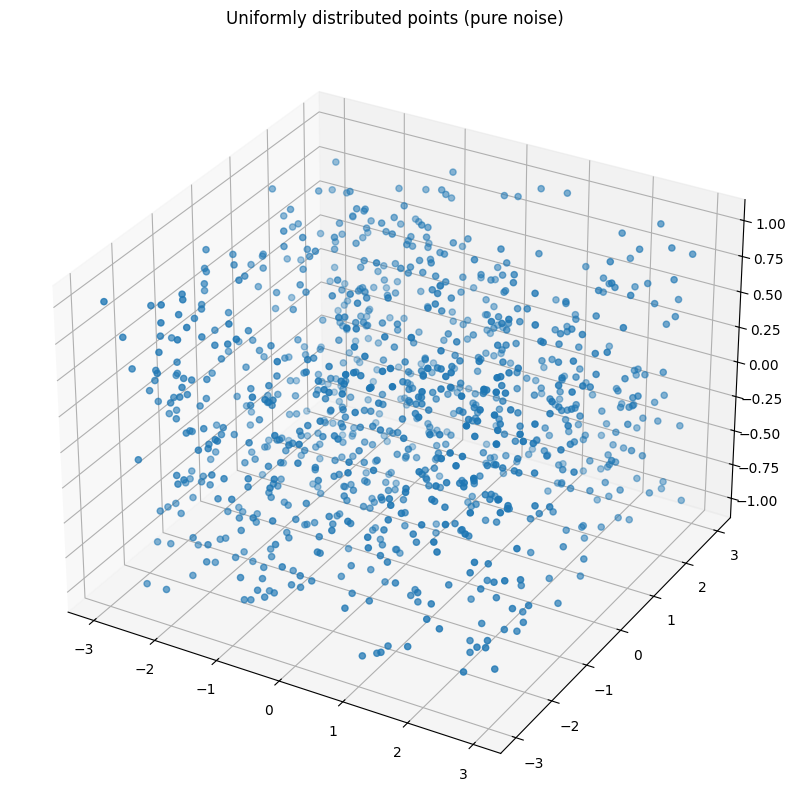

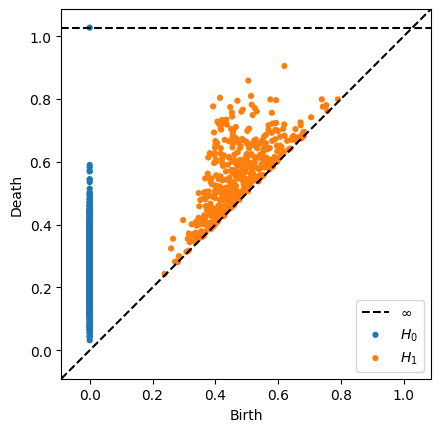

In [9]:
uniform_data = uniform_bounding_box_noise(data_torus, n_points=1000)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection="3d")
ax.scatter(uniform_data[:, 0], uniform_data[:, 1], uniform_data[:, 2])
ax.set_title("Uniformly distributed points (pure noise)")
plt.show()

dgm_uniform = ripser.ripser(uniform_data, maxdim=1)["dgms"]
persim.plot_diagrams(dgm_uniform, show=True)

## 1.3 Klein bottle in $\mathbb{R}^4$

A harder case: a non-orientable surface that cannot be embedded in $\mathbb{R}^3$ without
self-intersection. We sample it in $\mathbb{R}^4$ and project to $\mathbb{R}^3$ for display only.
The homology is always computed in the ambient $\mathbb{R}^4$.

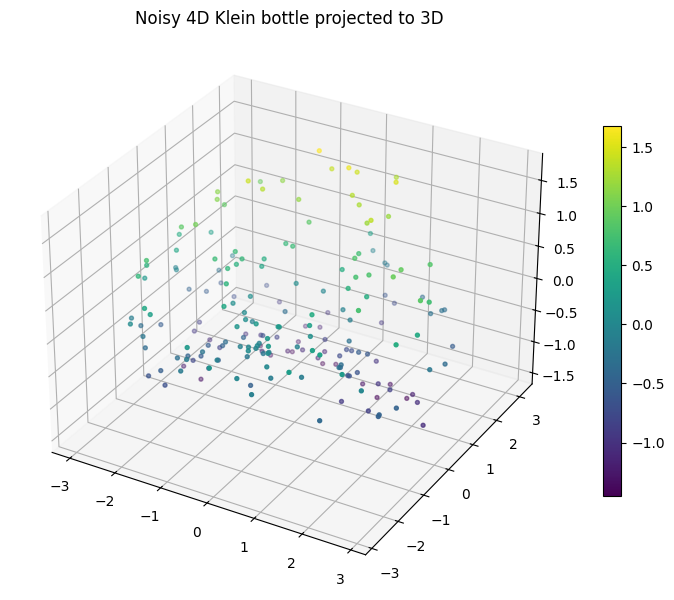

In [10]:
rng = np.random.default_rng(seed=123)

X_klein = klein_bottle_r4(n=200, rng=rng)
X_klein_noisy = klein_bottle_r4_noisy(n=200, sigma=0.1, rng=rng)
X_proj = project_r4_to_r3(X_klein_noisy)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")
sc = ax.scatter(X_proj[:, 0], X_proj[:, 1], X_proj[:, 2], c=X_proj[:, 2], cmap="viridis", s=8)
ax.set_title("Noisy 4D Klein bottle projected to 3D")
fig.colorbar(sc, ax=ax, shrink=0.6)
plt.show()

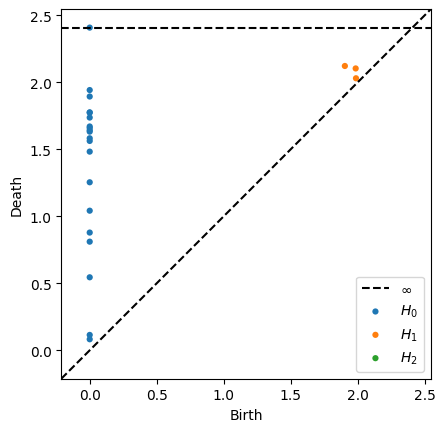

In [11]:
dgms_klein = ripser.ripser(klein_bottle_r4(n=20, rng=np.random.default_rng(123)), maxdim=2)["dgms"]
persim.plot_diagrams(dgms_klein, show=True)

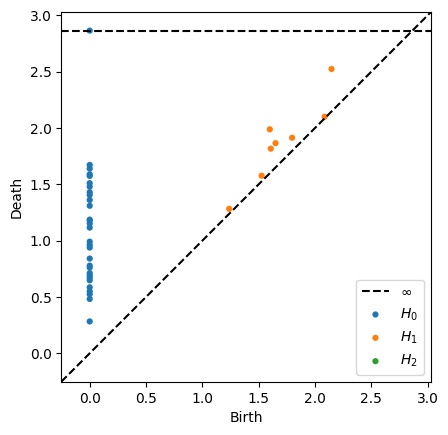

In [12]:
X_klein_noisy_30 = klein_bottle_r4_noisy(n=30, sigma=0.1, rng=np.random.default_rng(123))
dgms_klein_noisy = ripser.ripser(X_klein_noisy_30, maxdim=2)["dgms"]
persim.plot_diagrams(dgms_klein_noisy, show=True)

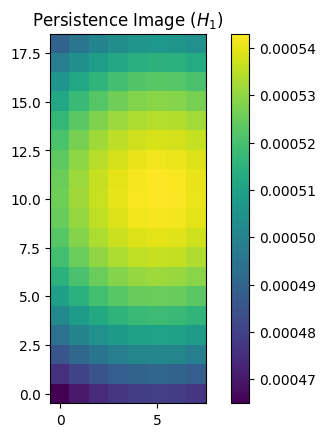

In [13]:
pimager = PersistenceImager(pixel_size=0.05)
pimager.fit(dgms_klein_noisy[1])
img = pimager.transform(dgms_klein_noisy[1])

plt.imshow(img, origin="lower")
plt.colorbar()
plt.title("Persistence Image ($H_1$)")
plt.show()

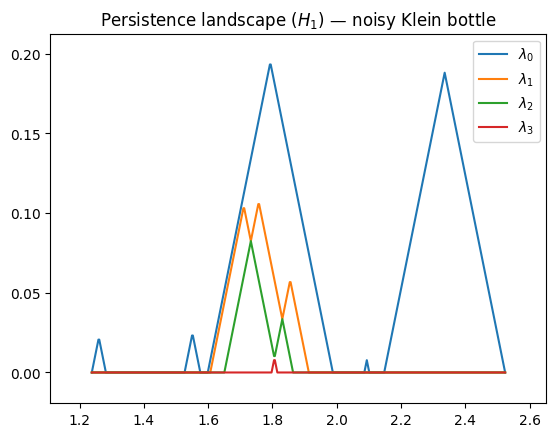

In [14]:
pla_klein = PersLandscapeApprox(dgms=dgms_klein_noisy, hom_deg=1)
ax = plot_landscape_simple(pla_klein, depth_range=range(10))
plt.title("Persistence landscape ($H_1$) — noisy Klein bottle")
plt.show()

## 1.4 Bottleneck distance: how far apart are two diagrams?

The bottleneck distance is the metric under which persistence diagrams are stable. Comparing
signal-vs-noise against noise-vs-noise shows it behaves as expected.

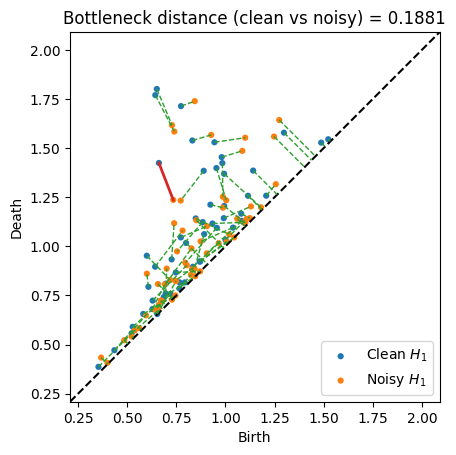

In [15]:
dgm_clean_h1 = ripser.ripser(X_klein)["dgms"][1]
dgm_noisy_h1 = ripser.ripser(X_klein_noisy)["dgms"][1]

distance_bottleneck, matching = bottleneck(dgm_clean_h1, dgm_noisy_h1, matching=True)
bottleneck_matching(dgm_clean_h1, dgm_noisy_h1, matching,
                    labels=["Clean $H_1$", "Noisy $H_1$"])
plt.title(f"Bottleneck distance (clean vs noisy) = {distance_bottleneck:0.4f}")
plt.show()

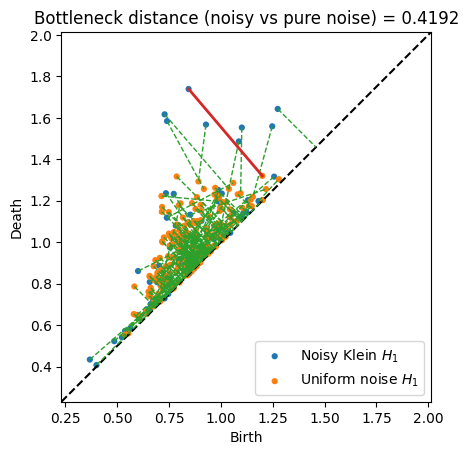

In [16]:
pure_noise_r4 = uniform_bounding_box_noise(X_klein, n_points=400)
dgm_uniform_h1 = ripser.ripser(pure_noise_r4)["dgms"][1]

distance_bottleneck, matching = bottleneck(dgm_noisy_h1, dgm_uniform_h1, matching=True)
bottleneck_matching(dgm_noisy_h1, dgm_uniform_h1, matching,
                    labels=["Noisy Klein $H_1$", "Uniform noise $H_1$"])
plt.title(f"Bottleneck distance (noisy vs pure noise) = {distance_bottleneck:0.4f}")
plt.show()

## Conclusion

The pipeline recovers the ground-truth topology of every shape tested, and short-lived features
stay near the diagonal under perturbation. The machinery behaves as it should.